# Классификация

## 1. MNIST

In [2]:
import matplotlib
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
X, y = mnist['data'], mnist['target']
print(X.shape, y.shape, sep='\n')


(70000, 784)
(70000,)


5


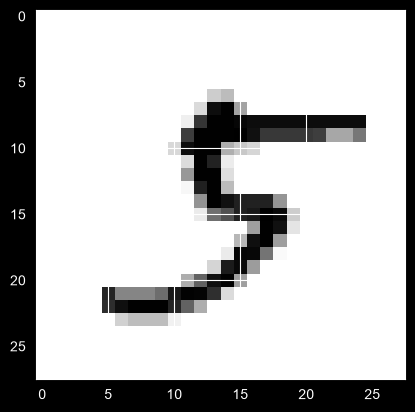

In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

some_digit = X[36011]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
print(y[36011])

In [5]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000].astype(int), y[60000:].astype(int)

In [6]:
import numpy as np
rng = np.random.default_rng(42)
permutation_indices = rng.permutation(len(X_train))

X_train, y_train = X_train[permutation_indices], y_train[permutation_indices]
print(X_train[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  45 154 239 254 255 226  91   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0 175 248 254 254 254 230 191  47   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  94 253 254 228 130  78  17   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 174 254 181  30   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0 174 254 137   0   0   0   0   0   0   5  2

## 2. Обучение двоичного классификатора

In [7]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [9]:
sgd_clf.predict([some_digit])

array([ True])

## 3. Показатели производительности

In [9]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.96005, 0.96585, 0.966  ])

### Матрица неточностей

In [10]:
from sklearn.model_selection import cross_val_predict
y_train_pred =  cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [11]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53501,  1078],
       [ 1084,  4337]])

Каждая строка в матрице неточностей представляет фактический класс, а каждый столбец - `спрогнозированный класс`. Первая строка матрицы учитывает изображения не пятерок (`отрицательный класс` (`negative class`)): 53501 из них были корректно классифицированы как не пятерки (`истинно отрицательные классификации`(`true negative` - `TN`)), тогда как оставшиеся 1078 были ошибочно классифицированы как пятерки (`ложноположительные классификации`(`false positive` - `FP`)). Вторая трока матрицы учитывает изображения пятерок (положительный класс (`positive class`)): 1084  были ошибочно классифицированы как не пятерки (`ложноотрицательные классификации`(`false negative` - `FN`)), в то время как оставшиеся 4337 были корректно классифицированы как пятерки (`истинно положительные классификации` (`true positive` - `TP`)). Безупречный классификатор имел бы только истинно положительные и истинно отрицательные классификации, так что его матрица
неточностей содержала бы ненулевые значения только на своей главной диагонали (от левого верхнего до правого нижнего угла)

### `Precision`
Матрица неточностей дает вам много информации, но иногда вы можете предпочесть более сжатую метрику. Интересной метрикой такого рода является аккуратность положительных классификаций; она назвается `precision` классификатора.
$$\text{точность} = \frac{TP}{TP + FP}$$

### `Recall`

Тривиальный способ добиться совершенной точности заключается в том, чтобы вырабатывать одну положительную классификацию и удостовериться в ее корректости (точность = 1/1 = 100%). Это было бы не особенно полезно, так как классификатор ингорировал бы все кроме одного положительного образца. Таким образом, точность обычно используется наряду с еще одной метрикой под название полнота (`recall`), также называемой чувствительностью (sensitivity) или долей истинно положительных классификаций (`True Positive Rate` - `TPR`)`: коэффициент положительных образцов, которые корректно обнаружены классификатором.
$$\text{полнота} = \frac{TP}{TP + FN}$$

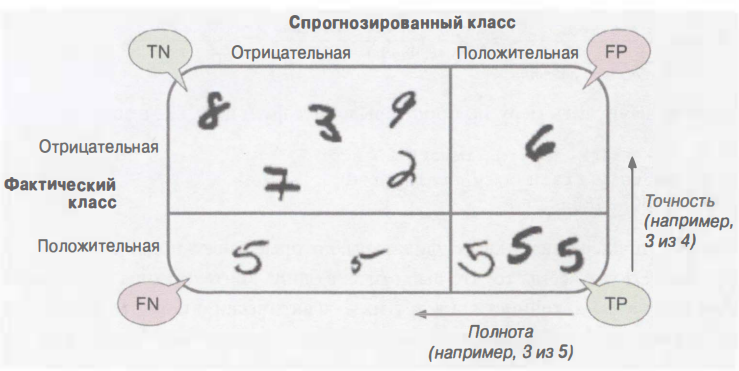

### `Точность и полнота (f1-мера)`
В Scikit-Learn предлагается несколько функций для подсчета метрик классификаторов, в том чисе точности и полноты:

In [12]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5, y_train_pred))
print(recall_score(y_train_5, y_train_pred))

0.8009233610341644
0.8000368935620734


Точность и полноту часто удобно объединять в единственную метрику под названием f1-мера, особенно если вам нужен простой способ сравнения двух классификаторов. Мера F1 - это среднее гармоническое точности и полноты. В то время как обычное среднее трактует все значения одинаково, среднее гармоническое придает низким значениям больший вес. В результате классификатор получит высокую меру F1, только если высокими являются и полнота, и точность.

In [13]:
from sklearn.metrics import f1_score
print(f1_score(y_train_5, y_train_pred))

0.8004798818752307


### Соотношение точность/полнота
Чтобы понять данное соотношение, давайте посмотрим, каким образом класс SGDClassifier принимает свои решения п оклассификации. Для кажддого образца он вычисляет сумму очков на основе функции решения (decision function), и если сумма очков больше какого-то порогового значения, тогда образец приписывается положительному классу, а иначе - отрицательному классу.

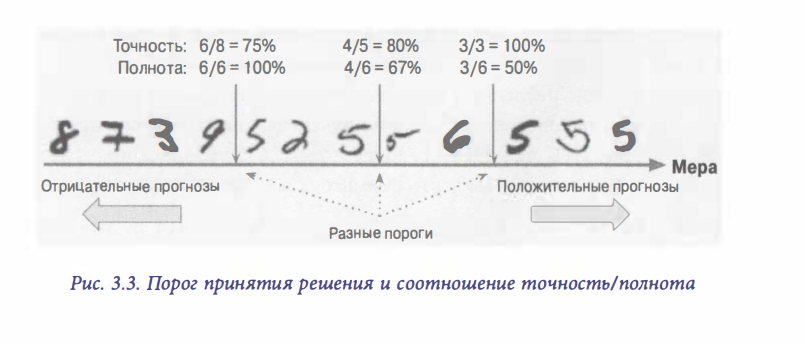

In [14]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([1092.92252135])

In [15]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

Класс `SGDClassifier` применяет порог равный 0, так что предыдущий код возвращает такой же результат, как и метод `predict()` (то есть True)

In [16]:
threshold = 5000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [17]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [18]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions.shape, recalls.shape, thresholds.shape)

(60001,) (60001,) (60000,)


In [19]:
plt.style.use('default')

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    ax.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Precision_and_Recall')
    ax.legend(loc='center left')
    ax.set_xlim([-50000, 50000])


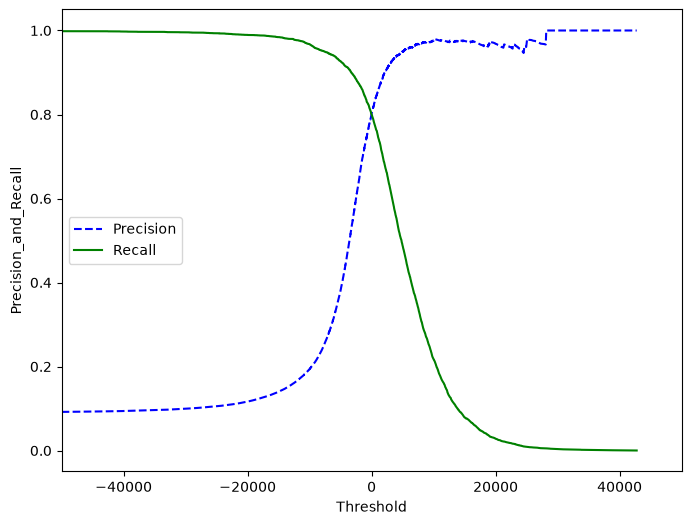

In [20]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

### Кривая ROC

Кривая рабочей характеристики приемника (`Receiver Operating Characteristic - ROC`) представляет собой еще один распространенный инструмент, применяемый с двоичными классификаторами. Она очень похожа на кривую точности-полноты (`precision-recall (PR) curve`), но вместо вычерчивания точности в сравнении с полнотой кривая `ROC` изображает долю истинно положительных классификаций (другое название полноты) по отношению к доле ложноположительных классификаций (`False Positive Rate - FPR`). Доля `FPR` - это пропорция отрицательных образцов, которые были некорректно классифицированы как положительные. Она равна единице минус доля истинно отрицательных классификаций (`True Negative Rate - TNR`), представляющая собой пропорцию отрицательных образцов, которые были корректно классифицированы как отрицательные.

Доля TNR также называется специфичностью (`specifity`). Следовательно, кривая ROC изображате чувствительность (`sensitivity`), то есть полноту, в сравнее с 1 - специфичность.

In [21]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [22]:
def plot_roc_curve(fpr, tpr):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, linewidth=2, label='ROC curve')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylim([0.0, 1.0])
    ax.set_xlim([0.0, 1.0])
    ax.set_ylabel('True Positive Rate')

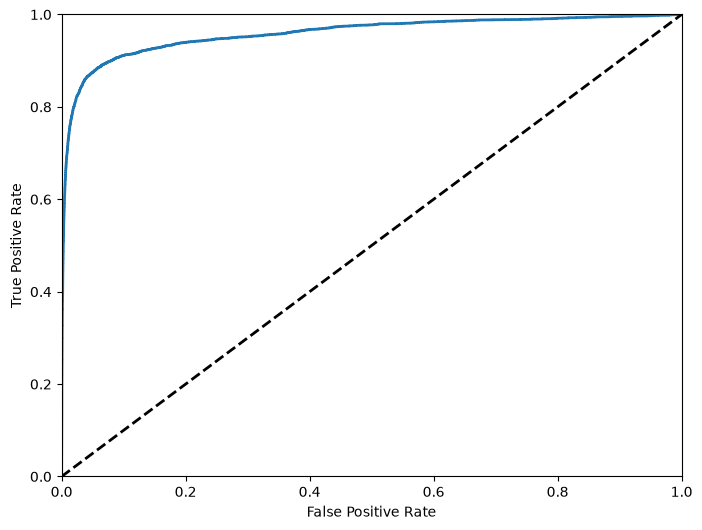

In [23]:
plot_roc_curve(fpr, tpr)

И снова имеет соотношение: чем выше полнота(TPR), тем больше классификатор дает ложноположительных классификаций (FPR). Пунктирная линия представляет кривую ROC чисто случайного классификатора.

### ROC - AUC

Один из способов сравнения классификаторов предусматривает измерение площади под кривой (Area Under the Curve - AUC). Безупречный классификатор будет иметь площадь под кривой ROC (ROC AUC), равную 1. тогда как чисто случайные классификатор - площадь 0.5.

In [24]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9588353891004884

In [25]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')
y_forest_pred = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict')

In [26]:
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

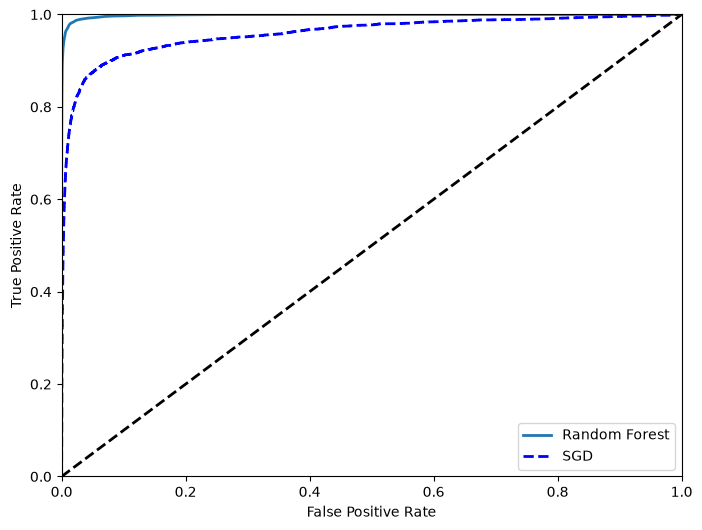

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_forest, tpr_forest, linewidth=2, label='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
ax.plot(fpr, tpr, 'b--', linewidth=2, label='SGD')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_ylim([0.0, 1.0])
ax.set_xlim([0.0, 1.0])
ax.legend(loc='lower right')

In [28]:
roc_auc_score(y_train_5, y_scores_forest)

0.9984169191459765

In [29]:
from sklearn.metrics import precision_score, recall_score


print(precision_score(y_train_5, y_forest_pred))
print(recall_score(y_train_5, y_forest_pred))

0.9900822958430049
0.8655229662423907


## Многоклассовая классификация

In [30]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([5])

In [31]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[ -9307.81732575,  -6997.61922019, -12578.78845588,
         -6029.3826648 ,  -9507.1196948 ,   2946.44536481,
        -27612.12953527,   1355.91308571,  -3487.66735705,
         -3464.38964481]])

In [32]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [33]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array([5])

In [34]:
forest_clf.fit(X_train, y_train)
forest_clf.predict([some_digit])

array([5])

In [35]:
s = cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')
s

array([0.8702 , 0.86525, 0.87005])

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
s_ = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')
s_

C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.90645, 0.90645, 0.90245])

## Анализ ошибок

In [37]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_m = confusion_matrix(y_train, y_train_pred)
conf_m

C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Vlad\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5611,    0,   18,    8,    8,   49,   33,    5,  188,    3],
       [   1, 6417,   43,   21,    3,   50,    4,   10,  179,   14],
       [  28,   29, 5260,   93,   70,   28,   71,   41,  328,   10],
       [  25,   17,  117, 5306,    0,  207,   25,   42,  324,   68],
       [  10,   13,   44,   13, 5276,   10,   41,   18,  267,  150],
       [  33,   18,   27,  176,   53, 4537,   76,   18,  416,   67],
       [  32,   19,   45,    3,   37,   94, 5569,    6,  113,    0],
       [  18,   13,   54,   29,   53,   14,    5, 5727,  134,  218],
       [  17,   64,   43,   95,    1,  135,   32,   11, 5406,   47],
       [  25,   22,   26,   55,  125,   42,    1,  171,  284, 5198]])

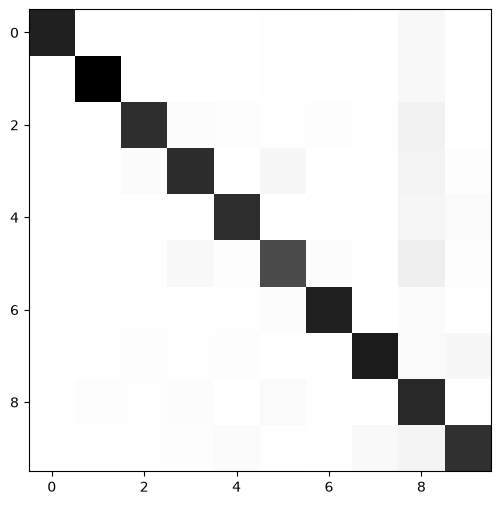

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(conf_m, interpolation='nearest', cmap='binary')

In [39]:
row_sums = conf_m.sum(axis=1, keepdims=True)
norm_conf_mx = conf_m / row_sums

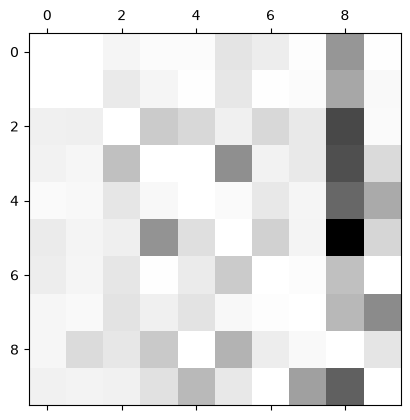

In [40]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap='binary')


# Упражнения

## 1. Классификатор точности 97%

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

k_neighbors = KNeighborsClassifier()

param_grid = {'n_neighbors': [5, 10, 20], 'weights': ['uniform', 'distance']}
grid_search_knn = GridSearchCV(k_neighbors, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')

In [11]:
grid_search_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [5, 10, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [12]:
grid_search_knn.best_score_

np.float64(0.9702166666666666)

In [13]:
grid_search_knn.best_params_

{'n_neighbors': 5, 'weights': 'distance'}

## 2. Расширение обучающего набора

In [14]:
def expand_data(X_train, y_train):
    X = X_train.copy()
    y = y_train.copy()

    def shift_left(digit):
        digit = np.pad(digit.reshape(28, 28), pad_width=1, mode='constant', constant_values=0)
        digit = np.roll(digit.reshape(900, -1), shift=-1)
        digit = (digit.reshape(30, 30)[1:29, 1:29]).reshape(784,)
        return digit


    def shift_right(digit):
        digit = np.pad(digit.reshape(28, 28), pad_width=1, mode='constant', constant_values=0)
        digit = np.roll(digit.reshape(900, 1), shift=-1)
        digit = (digit.reshape(30, 30)[1:29, 1:29]).reshape(784,)
        return digit


    def shift_up(digit):
        digit = np.pad(digit.reshape(28, 28), pad_width=1, mode='constant', constant_values=0)
        digit = np.roll(digit.reshape(900, 1), shift=-30)
        digit = (digit.reshape(30, 30)[1:29, 1:29]).reshape(784,)
        return digit


    def shift_down(digit):
        digit = np.pad(digit.reshape(28, 28), pad_width=1, mode='constant', constant_values=0)
        digit = np.roll(digit.reshape(900, 1), shift=30)
        digit = (digit.reshape(30, 30)[1:29, 1:29]).reshape(784,)
        return digit




    X_left = X.copy()
    for i in range(len(X)):
        X_left[i] = shift_left(X[i])

    X_right = X
    for i in range(len(X)):
        X_left[i] = shift_right(X[i])

    X_down = X
    for i in range(len(X)):
        X_left[i] = shift_down(X[i])

    X_up = X
    for i in range(len(X)):
        X_left[i] = shift_up(X[i])




    rng = np.random.default_rng(seed=42)
    indices = rng.permutation(5 * len(X))
    X = np.vstack([X, X_left, X_right, X_down, X_up])
    y = np.hstack([y, y, y, y, y])

    return X, y


In [15]:
X_train_expanded, y_train_expanded = expand_data(X_train, y_train)

### Классификатор на расширенных данных

In [16]:
from sklearn.model_selection import cross_val_score


k_neighbors = KNeighborsClassifier(n_neighbors=5, weights='distance')
scores = cross_val_score(k_neighbors, X_train_expanded, y_train_expanded, cv=3, scoring='accuracy')

In [17]:
print(scores)

[0.99402 0.99768 1.     ]
